# Przepływ optyczny

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

root_path = ""

## Implementacja metody blokowej

Text(0.5, 1.0, 'J')

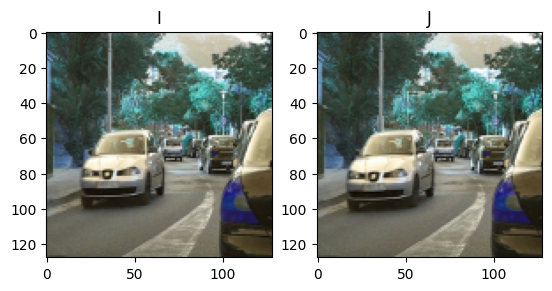

In [10]:
I = cv2.imread(root_path + "cm1.png")
J = cv2.imread(root_path + "cm2.png")

# I = cv2.imread(root_path + "I.jpg")
# J = cv2.imread(root_path + "J.jpg")

I = cv2.resize(I, None, fx=0.5, fy=0.5)
J = cv2.resize(J, None, fx=0.5, fy=0.5)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(I)
axes[0].set_title("I")
axes[1].imshow(J)
axes[1].set_title("J")

Text(0.5, 1.0, 'Gray Diff')

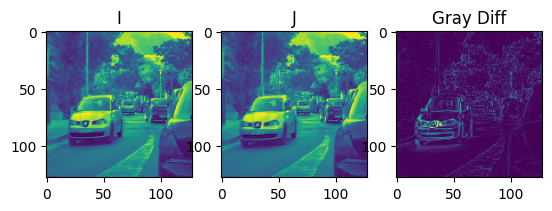

In [11]:
I_G = cv2.cvtColor(I, cv2.COLOR_BGR2GRAY)
J_G = cv2.cvtColor(J, cv2.COLOR_BGR2GRAY)
I_J_diff_G = cv2.absdiff(I_G, J_G)

fig, axes = plt.subplots(1, 3)
axes[0].imshow(I_G)
axes[0].set_title("I")
axes[1].imshow(J_G)
axes[1].set_title("J")
axes[2].imshow(I_J_diff_G)
axes[2].set_title("Gray Diff")

In [12]:
import copy


class OpticalFlowByMe:
    def __init__(self):
        pass

    def block_method(self, I: np.ndarray, J: np.ndarray, W2=3, dY=3, dX=3):
        if not isinstance(I , np.ndarray) or not isinstance(J , np.ndarray):
            print("Wrong type")
            return None
        if not I.shape == J.shape:
            print("Shape not matching")
            return None

        I_dXdt = np.zeros((I.shape[0], I.shape[1]))
        I_dYdt = np.zeros((I.shape[0], I.shape[1]))
        
        for row in range(2*dX, I.shape[0] - 2*dX):
            for col in range(2*dY, I.shape[1] - 2*dY):
                
                IO: np.ndarray = np.float32(I[int(row-W2):int(row+W2+1), int(col-W2):int(col+W2+1)])
                flow_map:dict = {}

                for ddX in range(-dX, dX+1):
                    contexRow = row+ddX
                    # if ddX+row>I.shape[0]:
                    #     ddX = I.shape[0]
                    # elif ddX+row<0:
                    #     ddX = 0

                    for ddY in range(-dY, dY+1):
                        contexCol = col+ddY
                        # if ddY+col>I.shape[0]:
                        #     ddY = I.shape[0]
                        # elif ddY+col<0:
                        #     ddY = 0

                        JO: np.ndarray = np.float32(J[int(contexRow-W2):int(contexRow+W2+1),int(contexCol-W2):int(contexCol+W2+1)])
                        flow_map[np.sqrt(np.sum((np.square(JO-IO))))] = (ddX, ddY)

                minimal_diff = min(flow_map.keys())
                (I_dXdt[row, col], I_dYdt[row, col]) = flow_map[minimal_diff]

        return (I_dXdt, I_dYdt)


    def calcHSV(self, I_flow):
        (I_dXdt, I_dYdt) = I_flow

        # minmax = [np.min(I_dXdt), np.min(I_dYdt), np.max(I_dXdt), np.max(I_dYdt)]
        # I_dXdt = I_dXdt/(np.max(np.abs(minmax)))
        # I_dYdt = I_dYdt/(np.max(np.abs(minmax)))

        # fig, axes = plt.subplots(1, 2)
        # axes[0].imshow(cv2.cvtColor((I_dXdt*255).astype(np.uint8), cv2.COLOR_GRAY2BGR))
        # axes[0].set_title("dX")
        # axes[1].imshow(cv2.cvtColor((I_dYdt*255).astype(np.uint8), cv2.COLOR_GRAY2BGR))
        # axes[1].set_title("dY")

        magnitude, angle = cv2.cartToPolar(I_dYdt.astype(float), I_dXdt.astype(float))

        hue = angle * 90 / np.pi

        saturation = cv2.normalize(magnitude, None, 0, 255, norm_type=cv2.NORM_MINMAX)
        mag_norm = 255


        hsv_image = np.zeros((I_dXdt.shape[0], I_dXdt.shape[1], 3), dtype=np.uint8)
        hsv_image[:, :, 0] = hue   
        hsv_image[:, :, 1] = saturation   
        hsv_image[:, :, 2] = mag_norm

        I_flow_HSV = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB)
        fig, axes = plt.subplots()
        axes.imshow(I_flow_HSV)
        axes.set_title("I_flow_HSV")
    
    def pyramid(self, im, max_scale):
        """ Tworzy piramidę obrazów przez wielokrotne skalowanie w dół. """
        images = [im]
        for k in range(1, max_scale):
            images.append(cv2.resize(images[k - 1], (0, 0), fx=0.5, fy=0.5))
        return images

    def of_scaling(self, I, J, maxscale, W2=3):
        YY, XX = I.shape[:2]
        maxScale = 2
        # Zmniejszenie rozmiaru obrazów dla szybkości obliczeń
        imagesI_pyramind  = self.pyramid(I, maxScale)
        imagesJ_pyramind  = self.pyramid(J, maxScale)

        u_total = np.zeros((YY, XX), dtype=np.float32)
        v_total = np.zeros((YY, XX), dtype=np.float32)
        I_new = imagesI_pyramind[-1] 

        I = imagesI_pyramind[-1]
        J = imagesJ_pyramind[-1]
        
        for k in range(maxScale-1, -1, -1):
            J = imagesJ_pyramind[k]
            print(maxScale-k)
            
            u, v = self.block_method(I, J, W2, W2, W2)
            # I_of = self.calcHSV((u, v))
            
            I_new = np.copy(I)
            YY_n, XX_n = I_new.shape[:2]
            for j in range(0, YY_n):
                for i in range(0, XX_n):
                    offset_i = int(u[j, i])
                    offset_j = int(v[j, i])
                    if (0 < i + offset_i < XX_n) and (0 < j + offset_j < YY_n):
                        I_new[j + offset_j, i + offset_i] = I[j, i]
                        
            I_new =  cv2.resize(I_new, (0, 0), fx=2, fy=2, interpolation=cv2.INTER_LINEAR)

            if k > 0:
                scale_factor = 2**k
                u_resized = cv2.resize(u, (XX, YY), interpolation=cv2.INTER_LINEAR) * scale_factor
                v_resized = cv2.resize(v, (XX, YY), interpolation=cv2.INTER_LINEAR) * scale_factor
                
                u_total += u_resized
                v_total += v_resized

            else:  
                u_total += u  
                v_total += v  
            
            I = I_new
            

            # Wizualizacja na każdej skali
            self.calcHSV((u_total, v_total))
        return u_total, v_total


optfl = OpticalFlowByMe()


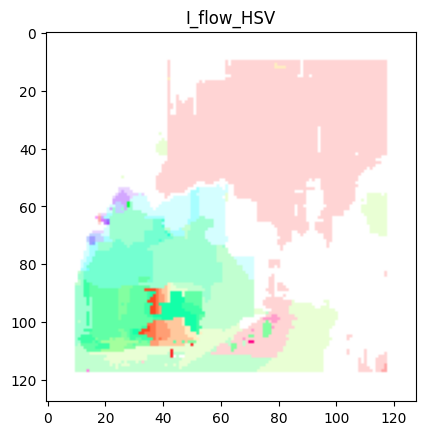

In [13]:
I_flow = optfl.block_method(I, J, W2 = 5, dX= 5, dY=5)
optfl.calcHSV(I_flow)

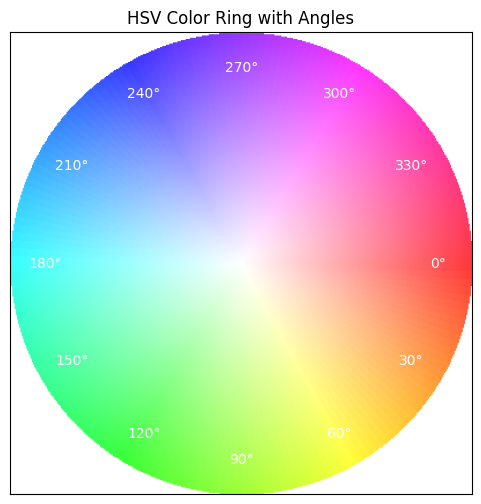

In [14]:
# Create coordinate grid
size = 400  # Image size
radius = size // 2
Y, X = np.meshgrid(np.arange(size) - radius, np.arange(size) - radius, indexing='xy')

# Compute polar coordinates
angle = (-1*(np.arctan2(Y, X) * 180 / np.pi)+90) % 360  # Angle in degrees (0-360)
distance = np.sqrt(X**2 + Y**2)

# Create HSV image (H: 0-179 in OpenCV)
hsv_image = np.zeros((size, size, 3), dtype=np.uint8)
hsv_image[..., 0] = (angle / 2).astype(np.uint8)  # Hue
hsv_image[..., 1] = np.where(distance < radius, distance, 0)  # Saturation
hsv_image[..., 2] =  255 # Value (keep ring)

# Convert to BGR for display
bgr_image = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2RGB)

# Plot the image
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(bgr_image)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("HSV Color Ring with Angles")

# Annotate angles
for angle in range(0, 360, 30):
    rad = np.deg2rad(angle)
    x = radius + int(radius * 0.85 * np.cos(rad))
    y = radius + int(radius * 0.85 * np.sin(rad))
    ax.text(x, y, f"{angle}°", color="white", fontsize=10, ha="center", va="center")

plt.show()


## Implementacja wyliczania w wielu skalach

1
2


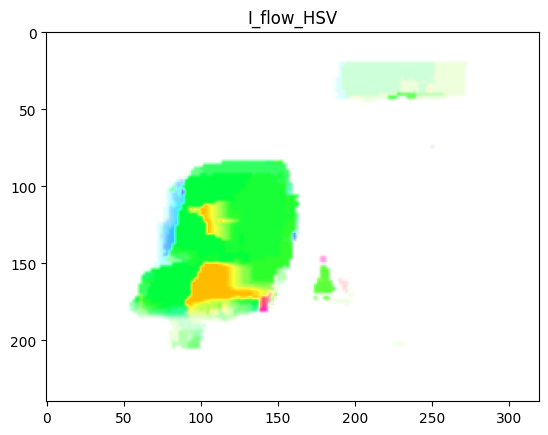

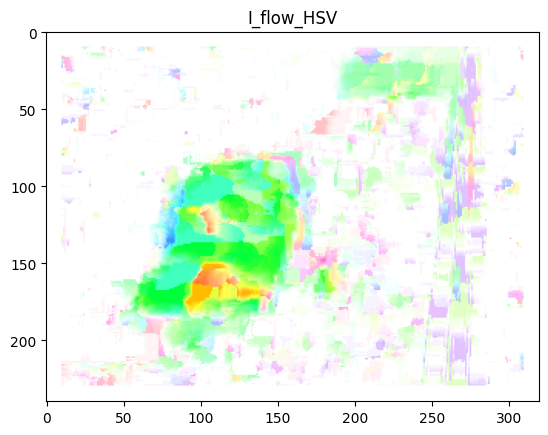

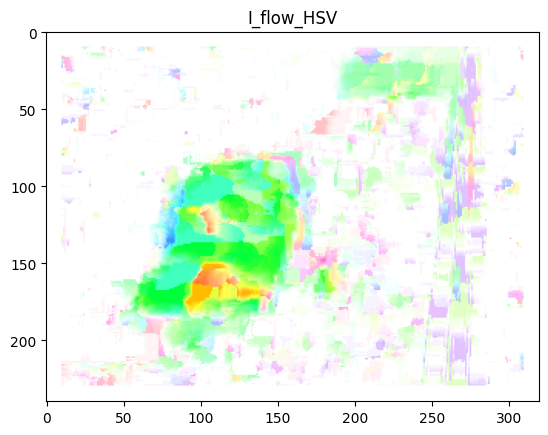

In [18]:
maxscale = 2
I = cv2.imread(root_path + "I.jpg")
J = cv2.imread(root_path + "J.jpg")

I_flow_pir = optfl.of_scaling(I, J, maxscale=maxscale, W2=5)
optfl.calcHSV(I_flow_pir)